In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 21.5 MB/s eta 0:00:00


## 1. Imports y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta

# Modelos
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Métricas y validación
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 2. Carga de datos

In [ ]:
# Datos de dengue
datos_dengue = pd.read_csv('datos_abiertos_vigilancia_dengue_2000_2024.csv', sep=';')

# Filtrar solo Iquitos
df_iquitos = datos_dengue[datos_dengue['distrito'] == 'IQUITOS'].copy()

# Datos climáticos de Iquitos
iquitos_weather = pd.read_csv('Iquitos_weather.csv', skiprows=16)

print(f'Registros de dengue (Iquitos): {len(df_iquitos):,}')
print(f'Registros climáticos: {len(iquitos_weather):,}')
print(f'Años disponibles dengue: {sorted(df_iquitos["ano"].unique())}')

Registros de dengue (Iquitos): 30,094
Registros climáticos: 9,132
Años disponibles dengue: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 3. Funciones de preprocesamiento

In [ ]:
def convertir_doy_a_fecha(df):
    """Convierte columnas YEAR + DOY a una columna Fecha."""
    df['Fecha'] = df.apply(
        lambda row: datetime(int(row['YEAR']), 1, 1) + timedelta(days=int(row['DOY']) - 1),
        axis=1
    )
    return df


def calcular_promedios_semanales(df):
    """Agrega datos diarios del clima en promedios semanales (ISO week)."""
    if not pd.api.types.is_datetime64_any_dtype(df['Fecha']):
        df['Fecha'] = pd.to_datetime(df['Fecha'])

    df['Week']     = df['Fecha'].apply(lambda x: x.isocalendar().week)
    df['ISO_Year'] = df['Fecha'].apply(lambda x: x.isocalendar().year)

    cols_clima = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'WS2M_MIN']
    weekly_avg = (
        df.groupby(['ISO_Year', 'Week'])[cols_clima]
        .mean()
        .reset_index()
        .rename(columns={'ISO_Year': 'Year', 'Week': 'Week_Number'})
    )
    return weekly_avg


def preprocesar_enfermedad(df):
    """Agrupa casos de dengue por año, semana y distrito."""
    cols_drop = ['departamento', 'provincia', 'localidad', 'enfermedad', 'edad', 'tipo_edad', 'sexo']
    df = df.drop(columns=cols_drop)

    df_grouped = (
        df.groupby(['ano', 'semana', 'distrito'])
        .size()
        .reset_index(name='numero_de_casos')
        .sort_values(['ano', 'semana'])
        .reset_index(drop=True)
    )
    return df_grouped


def unir_datasets(df_clima, df_enfermedad, distrito):
    """Une clima y enfermedad con LEFT JOIN (todas las semanas del clima, 0 casos si no hay datos)."""
    df_enfermedad_dist = df_enfermedad[df_enfermedad['distrito'] == distrito]
    df_clima = df_clima.rename(columns={'Year': 'ano', 'Week_Number': 'semana'})

    df_resultado = pd.merge(df_clima, df_enfermedad_dist, how='left', on=['ano', 'semana'])
    df_resultado['numero_de_casos'] = df_resultado['numero_de_casos'].fillna(0).astype(int)
    df_resultado['distrito'] = distrito
    return df_resultado


def construir_dataset(df_enfermedad, df_clima, distrito):
    """Pipeline completo de construcción del dataset final."""
    clima = df_clima.copy()
    clima = convertir_doy_a_fecha(clima)
    clima = calcular_promedios_semanales(clima)

    enf = preprocesar_enfermedad(df_enfermedad.copy())
    return unir_datasets(clima, enf, distrito)


print('✅ Funciones definidas')

✅ Funciones definidas


## 4. Construcción del dataset de Iquitos

In [ ]:
df = construir_dataset(df_iquitos, iquitos_weather, 'IQUITOS')

print(f'Shape final: {df.shape}')
print(f'Años: {df["ano"].min()} - {df["ano"].max()}')
print(f'Total de casos: {df["numero_de_casos"].sum():,}')
df.head()

Shape final: (1306, 12)
Años: 1999 - 2025
Total de casos: 29,991


,ano,semana,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,WS2M_MIN,distrito,numero_de_casos
0,1999,52,25.710000,28.195000,23.190000,0.055000,90.950000,0.275000,0.625000,0.035000,IQUITOS,0
1,2000,1,25.657143,28.912857,22.711429,0.281429,87.620000,0.250000,0.562857,0.055714,IQUITOS,7
2,2000,2,24.962857,27.410000,22.797143,5.175714,90.930000,0.275714,0.555714,0.052857,IQUITOS,7
3,2000,3,25.185714,27.815714,22.932857,15.854286,90.020000,0.265714,0.598571,0.030000,IQUITOS,15
4,2000,4,25.351429,28.275714,23.012857,3.082857,89.801429,0.260000,0.580000,0.038571,IQUITOS,8


## 5. Exploración rápida (2019–2024)

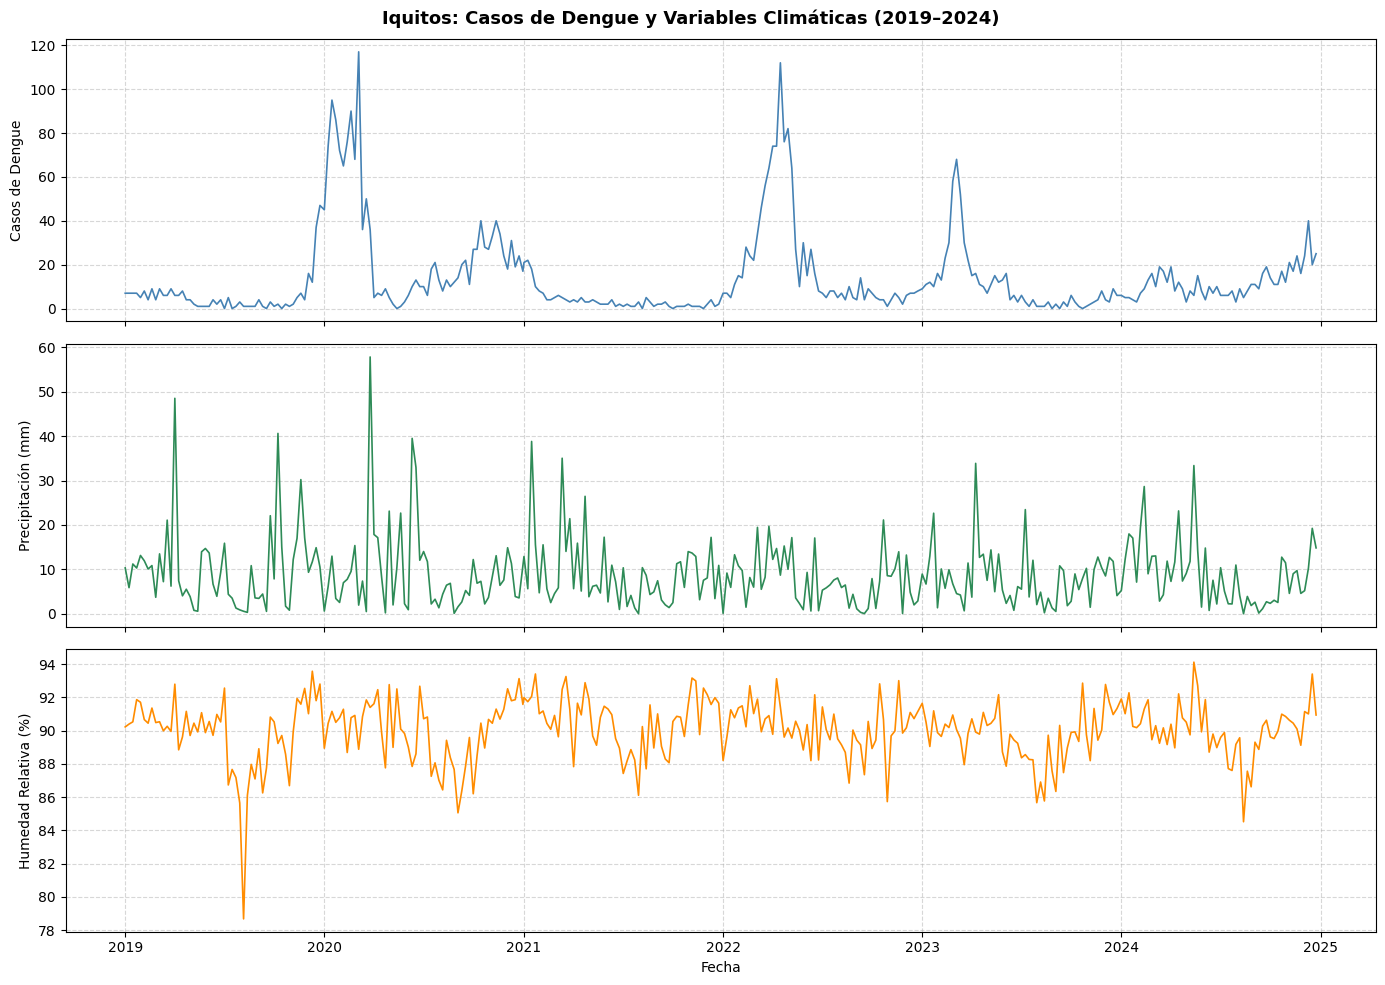

In [ ]:
target_years = [2019, 2020, 2021, 2022, 2023, 2024]
df_plot = df[df['ano'].isin(target_years)].copy()
df_plot['date'] = pd.to_datetime(df_plot['ano'].astype(str)) + \
                  pd.to_timedelta((df_plot['semana'] - 1) * 7, unit='D')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
vars_plot = ['numero_de_casos', 'PRECTOTCORR', 'RH2M']
colors    = ['steelblue', 'seagreen', 'darkorange']
labels    = ['Casos de Dengue', 'Precipitación (mm)', 'Humedad Relativa (%)']

for ax, var, color, label in zip(axes, vars_plot, colors, labels):
    ax.plot(df_plot['date'], df_plot[var], color=color, linewidth=1.2)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Fecha')
plt.suptitle('Iquitos: Casos de Dengue y Variables Climáticas (2019–2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Engineering — Lags + Features adicionales

In [ ]:
WEATHER_FEATURES = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'WS2M_MIN']
TARGET = 'numero_de_casos'

df_eng = df.copy()

# --- Lags del clima (1, 2 y 3 semanas) ---
for f in WEATHER_FEATURES:
    for lag in [1, 2, 3]:
        df_eng[f'{f}_lag{lag}'] = df_eng[f].shift(lag)

# --- Lags del target (autorregresión) ---
for lag in [1, 2, 3, 4]:
    df_eng[f'cases_lag{lag}'] = df_eng[TARGET].shift(lag)

# --- Rolling means del target (tendencia reciente) ---
df_eng['cases_roll4']  = df_eng[TARGET].shift(1).rolling(4).mean()
df_eng['cases_roll8']  = df_eng[TARGET].shift(1).rolling(8).mean()

# --- Features de temporada ---
df_eng['semana_sin'] = np.sin(2 * np.pi * df_eng['semana'] / 52)
df_eng['semana_cos'] = np.cos(2 * np.pi * df_eng['semana'] / 52)

# --- Interacciones clima ---
df_eng['temp_rango_lag1']  = df_eng['T2M_MAX_lag1'] - df_eng['T2M_MIN_lag1']
df_eng['lluvia_hum_lag1']  = df_eng['PRECTOTCORR_lag1'] * df_eng['RH2M_lag1']

df_eng = df_eng.dropna().reset_index(drop=True)

print(f'Dataset con features: {df_eng.shape}')
print(f'Features generadas: {df_eng.shape[1] - len(df.columns)}')

Dataset con features: (1298, 46)
Features generadas: 34


## 7. Definición de features y split temporal

In [ ]:
# Selección de features para el modelo
FEATURES = [
    # Autorregresión
    'cases_lag1', 'cases_lag2', 'cases_lag3', 'cases_lag4',
    'cases_roll4', 'cases_roll8',
    # Clima lag1
    'T2M_lag1', 'T2M_MAX_lag1', 'T2M_MIN_lag1',
    'PRECTOTCORR_lag1', 'RH2M_lag1',
    'WS2M_lag1', 'WS2M_MAX_lag1', 'WS2M_MIN_lag1',
    # Clima lag2
    'PRECTOTCORR_lag2', 'RH2M_lag2', 'T2M_lag2',
    # Clima lag3
    'PRECTOTCORR_lag3', 'RH2M_lag3',
    # Temporada
    'semana_sin', 'semana_cos',
    # Interacciones
    'temp_rango_lag1', 'lluvia_hum_lag1',
]

X = df_eng[FEATURES]
y = df_eng[TARGET]

# Split temporal: 80% train, 20% test
VAL_SIZE   = 0.20
split_idx  = int(len(df_eng) * (1 - VAL_SIZE))

X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)} semanas | Val: {len(X_val)} semanas')
print(f'Período train: año {df_eng.iloc[:split_idx]["ano"].min()} → {df_eng.iloc[:split_idx]["ano"].max()}')
print(f'Período val:   año {df_eng.iloc[split_idx:]["ano"].min()} → {df_eng.iloc[split_idx:]["ano"].max()}')

Train: 1038 semanas | Val: 260 semanas
Período train: año 2000 → 2020
Período val:   año 2020 → 2025


## 8. Función de métricas

In [ ]:
def calcular_metricas(y_true, y_pred, y_train_true, nombre='Modelo'):
    """Calcula R2, RMSE, MAE y MASE. Imprime y devuelve el diccionario."""
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # MASE: MAE del modelo / MAE del naive forecast (en entrenamiento)
    naive_mae = np.mean(np.abs(np.diff(y_train_true)))
    mase = mae / naive_mae

    print(f'\n{'='*35}')
    print(f'  {nombre}')
    print(f'{'='*35}')
    print(f'  R²    : {r2:.4f}')
    print(f'  RMSE  : {rmse:.4f}')
    print(f'  MAE   : {mae:.4f}')
    print(f'  MASE  : {mase:.4f}  ({"✅ Mejor" if mase < 1 else "❌ Peor"} que naive)')
    print(f'{'='*35}')

    return {'nombre': nombre, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MASE': mase}


def plot_prediccion(y_true, y_pred, metricas):
    """Gráfico de predicción vs real."""
    plt.figure(figsize=(14, 5))
    plt.plot(y_true.values, label='Real', color='black', linewidth=2)
    plt.plot(y_pred,        label='Predicción', color='red', linestyle='--', linewidth=1.5)
    plt.title(f"{metricas['nombre']} — R²: {metricas['R2']:.3f} | MASE: {metricas['MASE']:.3f}",
              fontsize=13, fontweight='bold')
    plt.xlabel('Semana (índice)')
    plt.ylabel('Número de casos')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print('✅ Funciones de métricas definidas')

✅ Funciones de métricas definidas


## 9. Baseline — Random Forest (configuración original)


  Random Forest Baseline
  R²    : 0.7780
  RMSE  : 9.4342
  MAE   : 5.6655
  MASE  : 0.5937  (✅ Mejor que naive)


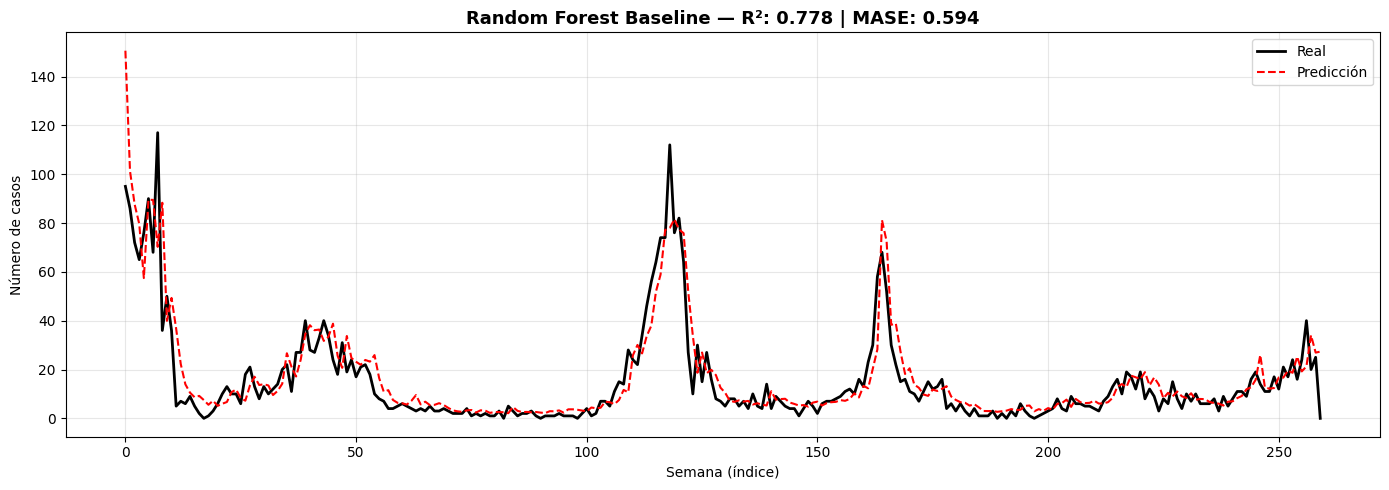

In [ ]:
rf_base = RandomForestRegressor(
    criterion='absolute_error',
    n_estimators=200,
    max_features=0.6,
    max_depth=50,
    bootstrap=True,
    random_state=18,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
y_pred_rf_base = rf_base.predict(X_val)

metricas_rf_base = calcular_metricas(y_val, y_pred_rf_base, y_train, 'Random Forest Baseline')
plot_prediccion(y_val, y_pred_rf_base, metricas_rf_base)

## 10. TimeSeriesSplit Cross-Validation — comparar modelos base

In [ ]:
def cv_temporal(modelo, X, y, n_splits=5, nombre=''):
    """Cross-validation temporal con TimeSeriesSplit. Devuelve MASE promedio."""
    tscv  = TimeSeriesSplit(n_splits=n_splits)
    mases = []
    r2s   = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

        modelo.fit(X_tr, y_tr)
        y_pr = modelo.predict(X_vl)

        r2   = r2_score(y_vl, y_pr)
        mae  = mean_absolute_error(y_vl, y_pr)
        naive_mae = np.mean(np.abs(np.diff(y_tr.values)))
        mase = mae / naive_mae if naive_mae > 0 else np.inf

        mases.append(mase)
        r2s.append(r2)

    print(f'{nombre:30s} | CV R²: {np.mean(r2s):.3f} ± {np.std(r2s):.3f} | CV MASE: {np.mean(mases):.3f} ± {np.std(mases):.3f}')
    return {'R2_cv': np.mean(r2s), 'MASE_cv': np.mean(mases)}


# Modelos base a comparar (sin tuning)
modelos_base = {
    'Random Forest'  : RandomForestRegressor(n_estimators=200, max_features=0.6, max_depth=50,
                                              criterion='absolute_error', random_state=18, n_jobs=-1),
    'XGBoost'        : XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                    subsample=0.8, colsample_bytree=0.8, random_state=18, n_jobs=-1, verbosity=0),
    'LightGBM'       : LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                     subsample=0.8, colsample_bytree=0.8, random_state=18, n_jobs=-1, verbose=-1),
}

print('Cross-Validation Temporal (5 folds):')
print('-' * 70)
resultados_cv = {}
for nombre, modelo in modelos_base.items():
    resultados_cv[nombre] = cv_temporal(modelo, X_train, y_train, n_splits=5, nombre=nombre)

Cross-Validation Temporal (5 folds):
----------------------------------------------------------------------
Random Forest                  | CV R²: 0.558 ± 0.218 | CV MASE: 2.283 ± 2.324
XGBoost                        | CV R²: 0.530 ± 0.228 | CV MASE: 2.392 ± 2.445
LightGBM                       | CV R²: 0.046 ± 0.730 | CV MASE: 2.605 ± 2.338


## 11. Tuning con Optuna

In [ ]:
def objective_rf(trial):
    params = {
        'n_estimators'  : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'     : trial.suggest_int('max_depth', 5, 60),
        'max_features'  : trial.suggest_float('max_features', 0.3, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
    }
    modelo = RandomForestRegressor(**params, criterion='absolute_error', random_state=18, n_jobs=-1)
    res = cv_temporal(modelo, X_train, y_train, n_splits=5, nombre='')
    return res['MASE_cv']

def objective_xgb(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 600),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0, 5),
    }
    modelo = XGBRegressor(**params, random_state=18, n_jobs=-1, verbosity=0)
    res = cv_temporal(modelo, X_train, y_train, n_splits=5, nombre='')
    return res['MASE_cv']

def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'num_leaves'       : trial.suggest_int('num_leaves', 15, 127),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 5),
    }
    modelo = LGBMRegressor(**params, random_state=18, n_jobs=-1, verbose=-1)
    res = cv_temporal(modelo, X_train, y_train, n_splits=5, nombre='')
    return res['MASE_cv']

N_TRIALS = 50  # Puedes subir a 100 si tienes más tiempo

print(f'🔍 Tuning Random Forest ({N_TRIALS} trials)...')
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=True)
print(f'✅ Mejor MASE RF:    {study_rf.best_value:.4f} | Params: {study_rf.best_params}')

print(f'\n🔍 Tuning XGBoost ({N_TRIALS} trials)...')
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print(f'✅ Mejor MASE XGB:   {study_xgb.best_value:.4f} | Params: {study_xgb.best_params}')

print(f'\n🔍 Tuning LightGBM ({N_TRIALS} trials)...')
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
print(f'✅ Mejor MASE LGBM:  {study_lgbm.best_value:.4f} | Params: {study_lgbm.best_params}')

🔍 Tuning Random Forest (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

                               | CV R²: 0.515 ± 0.218 | CV MASE: 2.350 ± 2.393
                               | CV R²: 0.453 ± 0.215 | CV MASE: 2.492 ± 2.423
                               | CV R²: 0.549 ± 0.209 | CV MASE: 2.306 ± 2.323
                               | CV R²: 0.457 ± 0.216 | CV MASE: 2.483 ± 2.421
                               | CV R²: 0.415 ± 0.227 | CV MASE: 2.572 ± 2.457
                               | CV R²: 0.426 ± 0.226 | CV MASE: 2.550 ± 2.442
                               | CV R²: 0.409 ± 0.227 | CV MASE: 2.579 ± 2.469
                               | CV R²: 0.434 ± 0.222 | CV MASE: 2.534 ± 2.441
                               | CV R²: 0.514 ± 0.212 | CV MASE: 2.348 ± 2.370
                               | CV R²: 0.395 ± 0.226 | CV MASE: 2.596 ± 2.465
                               | CV R²: 0.544 ± 0.213 | CV MASE: 2.301 ± 2.341
                               | CV R²: 0.552 ± 0.214 | CV MASE: 2.308 ± 2.335
                               | CV R²: 0.553 ± 0.21

  0%|          | 0/50 [00:00<?, ?it/s]

                               | CV R²: 0.475 ± 0.174 | CV MASE: 2.417 ± 2.334
                               | CV R²: 0.507 ± 0.209 | CV MASE: 2.417 ± 2.383
                               | CV R²: 0.470 ± 0.183 | CV MASE: 2.400 ± 2.330
                               | CV R²: 0.455 ± 0.168 | CV MASE: 2.395 ± 2.252
                               | CV R²: 0.287 ± 0.317 | CV MASE: 2.667 ± 2.452
                               | CV R²: 0.468 ± 0.171 | CV MASE: 2.413 ± 2.338
                               | CV R²: 0.477 ± 0.183 | CV MASE: 2.428 ± 2.352
                               | CV R²: 0.529 ± 0.210 | CV MASE: 2.309 ± 2.320
                               | CV R²: 0.494 ± 0.195 | CV MASE: 2.325 ± 2.318
                               | CV R²: 0.512 ± 0.207 | CV MASE: 2.308 ± 2.319
                               | CV R²: 0.536 ± 0.221 | CV MASE: 2.381 ± 2.430
                               | CV R²: 0.526 ± 0.206 | CV MASE: 2.304 ± 2.333
                               | CV R²: 0.522 ± 0.20

  0%|          | 0/50 [00:00<?, ?it/s]

                               | CV R²: 0.341 ± 0.302 | CV MASE: 2.458 ± 2.338
                               | CV R²: -1.094 ± 2.538 | CV MASE: 3.150 ± 2.332
                               | CV R²: 0.233 ± 0.109 | CV MASE: 2.690 ± 2.335
                               | CV R²: 0.175 ± 0.297 | CV MASE: 2.766 ± 2.396
                               | CV R²: -1.285 ± 2.848 | CV MASE: 3.199 ± 2.266
                               | CV R²: 0.502 ± 0.189 | CV MASE: 2.405 ± 2.337
                               | CV R²: -0.127 ± 0.899 | CV MASE: 2.731 ± 2.295
                               | CV R²: -1.168 ± 2.314 | CV MASE: 3.176 ± 2.307
                               | CV R²: 0.186 ± 0.226 | CV MASE: 2.746 ± 2.400
                               | CV R²: -0.275 ± 0.757 | CV MASE: 3.012 ± 2.395
                               | CV R²: 0.490 ± 0.171 | CV MASE: 2.374 ± 2.310
                               | CV R²: 0.494 ± 0.172 | CV MASE: 2.379 ± 2.312
                               | CV R²: 0.521 ±

## 12. Evaluación final — Modelos tuneados en el set de validación


  Random Forest Tuneado
  R²    : 0.7925
  RMSE  : 9.1200
  MAE   : 5.4600
  MASE  : 0.5722  (✅ Mejor que naive)


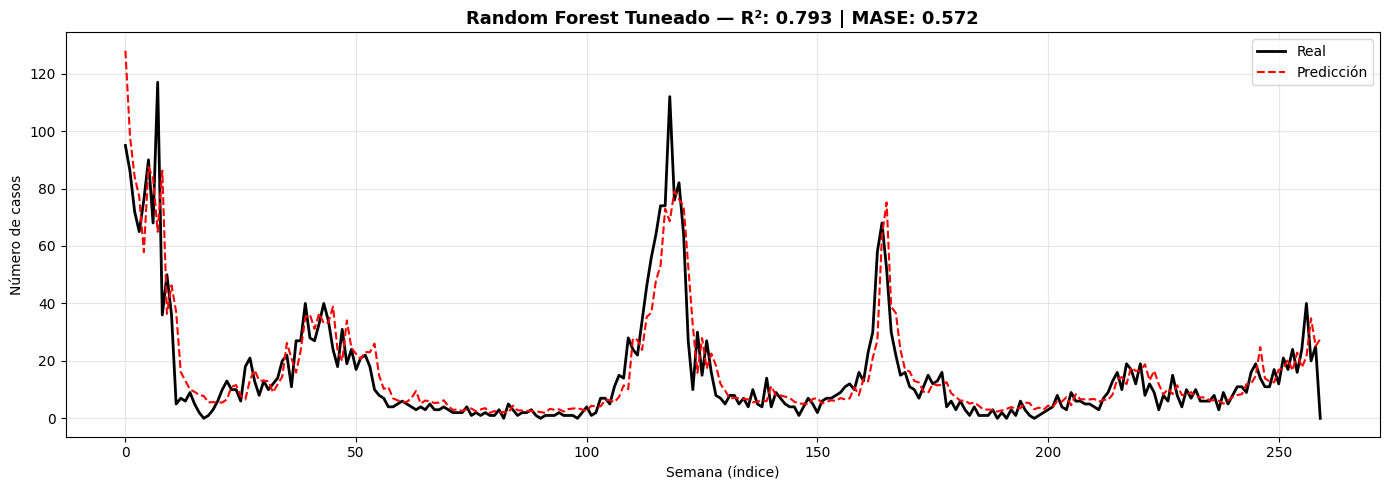


  XGBoost Tuneado
  R²    : 0.8024
  RMSE  : 8.9011
  MAE   : 5.3033
  MASE  : 0.5558  (✅ Mejor que naive)


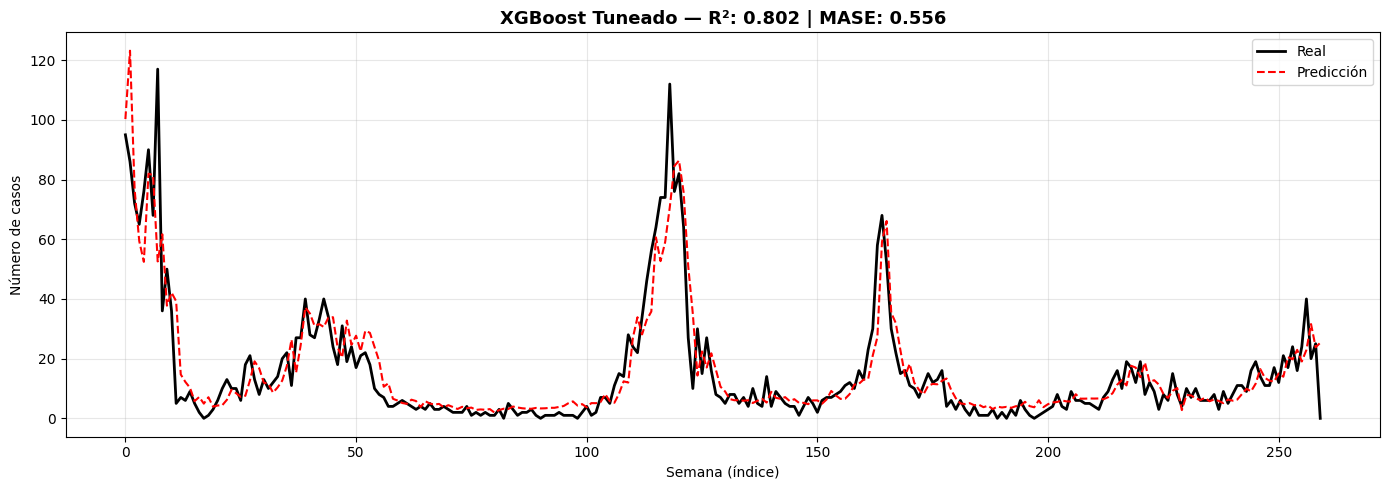


  LightGBM Tuneado
  R²    : 0.8062
  RMSE  : 8.8138
  MAE   : 5.4411
  MASE  : 0.5702  (✅ Mejor que naive)


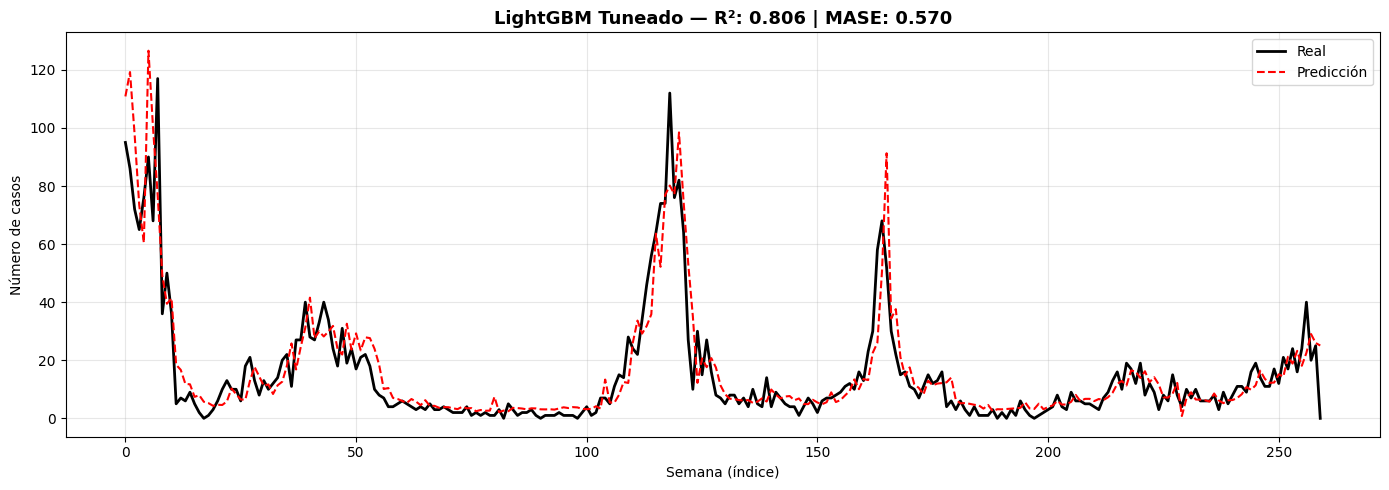

In [ ]:
# Entrenar cada modelo tuneado con TODO el train set y evaluar en val
resultados_finales = []

# --- Random Forest tuneado ---
rf_tuned = RandomForestRegressor(**study_rf.best_params, criterion='absolute_error', random_state=18, n_jobs=-1)
rf_tuned.fit(X_train, y_train)
y_pred_rf = rf_tuned.predict(X_val)
m_rf = calcular_metricas(y_val, y_pred_rf, y_train, 'Random Forest Tuneado')
resultados_finales.append(m_rf)
plot_prediccion(y_val, y_pred_rf, m_rf)

# --- XGBoost tuneado ---
xgb_tuned = XGBRegressor(**study_xgb.best_params, random_state=18, n_jobs=-1, verbosity=0)
xgb_tuned.fit(X_train, y_train)
y_pred_xgb = xgb_tuned.predict(X_val)
m_xgb = calcular_metricas(y_val, y_pred_xgb, y_train, 'XGBoost Tuneado')
resultados_finales.append(m_xgb)
plot_prediccion(y_val, y_pred_xgb, m_xgb)

# --- LightGBM tuneado ---
lgbm_tuned = LGBMRegressor(**study_lgbm.best_params, random_state=18, n_jobs=-1, verbose=-1)
lgbm_tuned.fit(X_train, y_train)
y_pred_lgbm = lgbm_tuned.predict(X_val)
m_lgbm = calcular_metricas(y_val, y_pred_lgbm, y_train, 'LightGBM Tuneado')
resultados_finales.append(m_lgbm)
plot_prediccion(y_val, y_pred_lgbm, m_lgbm)

## 13. Tabla comparativa de resultados


📊 Comparación de modelos (ordenado por MASE):
                           R2   RMSE    MAE   MASE
nombre                                            
XGBoost Tuneado        0.8024 8.9011 5.3033 0.5558
LightGBM Tuneado       0.8062 8.8138 5.4411 0.5702
Random Forest Tuneado  0.7925 9.1200 5.4600 0.5722
Random Forest Baseline 0.7780 9.4342 5.6655 0.5937


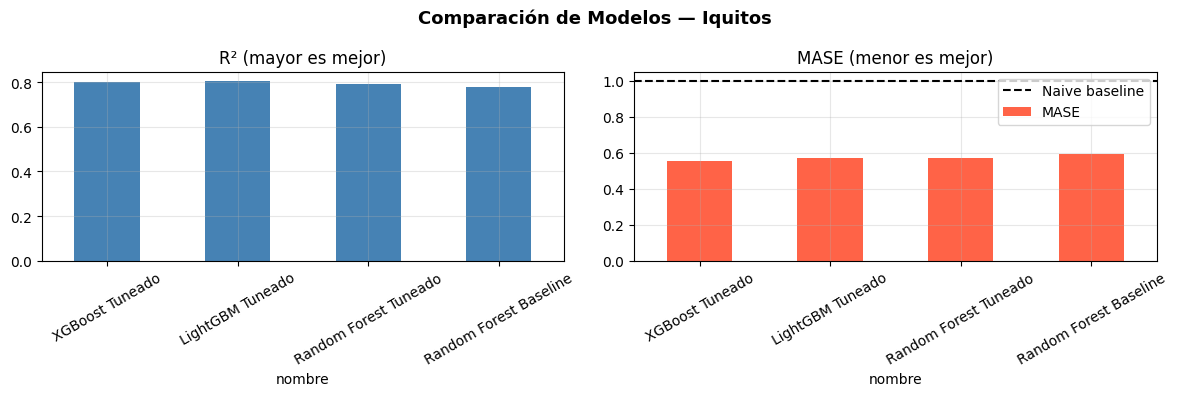

In [ ]:
# Agregar baseline al resumen
todos = [metricas_rf_base] + resultados_finales
df_resultados = pd.DataFrame(todos).set_index('nombre')
df_resultados = df_resultados.sort_values('MASE')

print('\n📊 Comparación de modelos (ordenado por MASE):')
print(df_resultados.to_string(float_format='{:.4f}'.format))

# Gráfico resumen
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_resultados['R2'].plot(kind='bar', ax=axes[0], color='steelblue', title='R² (mayor es mejor)')
df_resultados['MASE'].plot(kind='bar', ax=axes[1], color='tomato',   title='MASE (menor es mejor)')
axes[1].axhline(y=1, color='black', linestyle='--', label='Naive baseline')
axes[1].legend()
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)
plt.suptitle('Comparación de Modelos — Iquitos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Feature Importance — Mejor modelo

🏆 Mejor modelo: XGBoost Tuneado


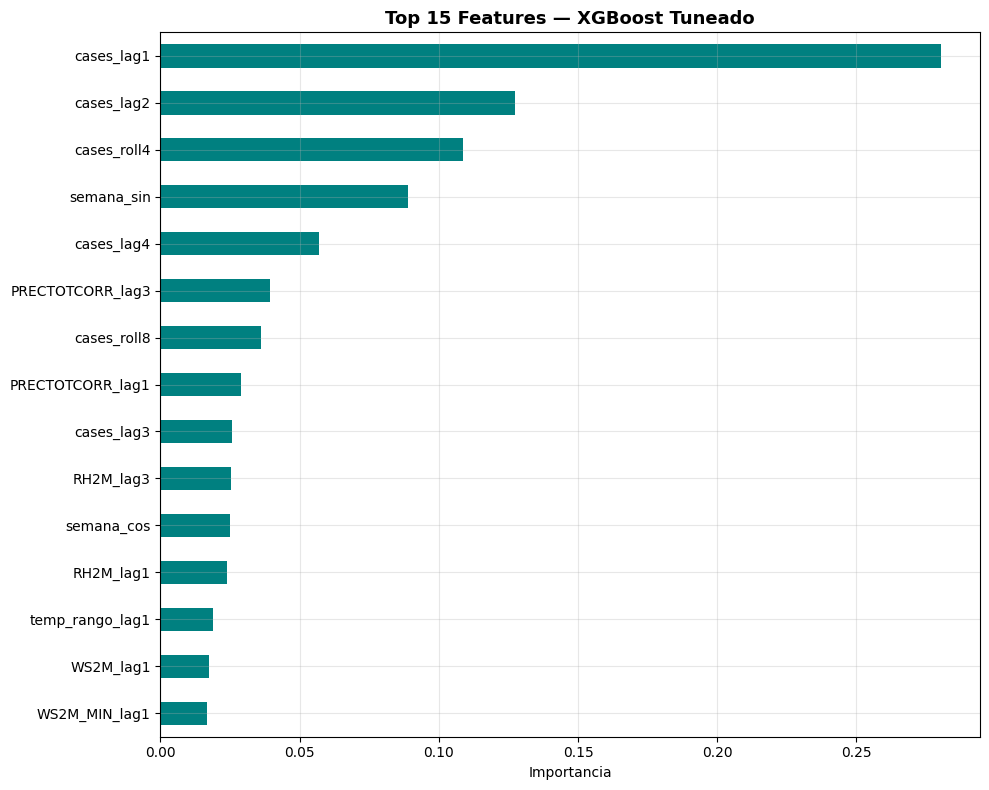

In [ ]:
# Identificar el mejor modelo por MASE
mejor_nombre = df_resultados['MASE'].idxmin()
print(f'🏆 Mejor modelo: {mejor_nombre}')

# Obtener importancias
modelos_dict = {
    'Random Forest Baseline' : rf_base,
    'Random Forest Tuneado'  : rf_tuned,
    'XGBoost Tuneado'        : xgb_tuned,
    'LightGBM Tuneado'       : lgbm_tuned,
}
mejor_modelo = modelos_dict[mejor_nombre]

importances = pd.Series(mejor_modelo.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.tail(15).plot(kind='barh', color='teal')
plt.title(f'Top 15 Features — {mejor_nombre}', fontsize=13, fontweight='bold')
plt.xlabel('Importancia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import json

# ============================================================
# EXPORTAR DATOS Y MODELO PARA EXPLICABILIDAD — IQUITOS
# Agrega esta celda AL FINAL de tu notebook, después de entrenar
# ============================================================

# 1. Exportar splits de datos
X_train.to_csv('X_train_Iquitos.csv', index=False)
X_val.to_csv('X_val_Iquitos.csv',   index=False)
y_train.to_csv('y_train_Iquitos.csv', index=False, header=True)
y_val.to_csv('y_val_Iquitos.csv',   index=False, header=True)

print(f'✅ X_train guardado: {X_train.shape}')
print(f'✅ X_val guardado:   {X_val.shape}')
print(f'✅ y_train guardado: {y_train.shape}')
print(f'✅ y_val guardado:   {y_val.shape}')

# 2. Exportar el modelo entrenado
joblib.dump(rf_tuned, 'modelo_rf_iquitos.pkl')
print('✅ Modelo guardado: modelo_rf_iquitos.pkl')

# 3. Exportar los mejores parámetros en JSON (referencia)
params = study_rf.best_params
params['criterion']    = 'absolute_error'
params['random_state'] = 18

with open('params_rf_iquitos.json', 'w') as f:
    json.dump(params, f, indent=2)

print('✅ Parámetros guardados: params_rf_iquitos.json')
print('\n📋 Parámetros del mejor modelo:')
for k, v in params.items():
    print(f'   {k}: {v}')

# 4. Si estás en Google Colab, descargar automáticamente
try:
    from google.colab import files
    files.download('X_train_Iquitos.csv')
    files.download('X_val_Iquitos.csv')
    files.download('y_train_Iquitos.csv')
    files.download('y_val_Iquitos.csv')
    files.download('modelo_rf_iquitos.pkl')
    files.download('params_rf_iquitos.json')
    print('✅ Descarga iniciada en Colab')
except ImportError:
    print('ℹ️  No estás en Colab — los archivos quedaron guardados en el directorio actual')

✅ X_train guardado: (1038, 23)
✅ X_val guardado:   (260, 23)
✅ y_train guardado: (1038,)
✅ y_val guardado:   (260,)
✅ Modelo guardado: modelo_rf_iquitos.pkl
✅ Parámetros guardados: params_rf_iquitos.json

📋 Parámetros del mejor modelo:
   n_estimators: 185
   max_depth: 57
   max_features: 0.9114320765592469
   min_samples_split: 12
   min_samples_leaf: 1
   criterion: absolute_error
   random_state: 18


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga iniciada en Colab


In [ ]:
import joblib
import json

# ============================================================
# EXPORTAR DATOS Y MODELO PARA EXPLICABILIDAD — IQUITOS
# Agrega esta celda AL FINAL de tu notebook, después de entrenar
# ============================================================

# 1. Exportar splits de datos
X_train.to_csv('X_train_Iquitos.csv', index=False)
X_val.to_csv('X_val_Iquitos.csv',     index=False)
y_train.to_csv('y_train_Iquitos.csv', index=False, header=True)
y_val.to_csv('y_val_Iquitos.csv',     index=False, header=True)

print(f'✅ X_train guardado: {X_train.shape}')
print(f'✅ X_val guardado:   {X_val.shape}')
print(f'✅ y_train guardado: {y_train.shape}')
print(f'✅ y_val guardado:   {y_val.shape}')

# 2. Exportar el modelo LightGBM entrenado
joblib.dump(lgbm_tuned, 'modelo_lgbm_iquitos.pkl')
print('✅ Modelo guardado: modelo_lgbm_iquitos.pkl')

# 3. Exportar los mejores parámetros en JSON
params = study_lgbm.best_params.copy()
params['random_state'] = 18

with open('params_lgbm_iquitos.json', 'w') as f:
    json.dump(params, f, indent=2)

print('✅ Parámetros guardados: params_lgbm_iquitos.json')
print('\n📋 Parámetros del mejor modelo LightGBM:')
for k, v in params.items():
    print(f'   {k}: {v}')

✅ X_train guardado: (1038, 23)
✅ X_val guardado:   (260, 23)
✅ y_train guardado: (1038,)
✅ y_val guardado:   (260,)
✅ Modelo guardado: modelo_lgbm_iquitos.pkl
✅ Parámetros guardados: params_lgbm_iquitos.json

📋 Parámetros del mejor modelo LightGBM:
   n_estimators: 314
   learning_rate: 0.024702160106817823
   max_depth: 5
   num_leaves: 59
   subsample: 0.9105086938032918
   colsample_bytree: 0.6365581958461825
   min_child_samples: 10
   reg_alpha: 1.2850959546815541
   reg_lambda: 3.2619364052236746
   random_state: 18
